# Monte Carlo para Estimación de Parámetros
### Integración, Propagación de Incertidumbre e Intervalos de Confianza

**Magíster en Ciencia de Datos e Inteligencia Artificial** · Universidad Andrés Bello

Maidana, J.P. (2026)

---

> **Cómo usar este cuaderno.** Ejecuta las celdas en orden de arriba hacia abajo. Cada ejemplo es autocontenido (define sus propias funciones), así que también puedes correrlos por separado tras ejecutar la celda de configuración inicial.

In [1]:
# ---------------------------------------------------------------
# CONFIGURACIÓN — ejecutar primero
# ---------------------------------------------------------------
# Requisitos: numpy, scipy, matplotlib (todos preinstalados en Google Colab).
# Si te faltara alguno, descomenta:
# !pip install numpy scipy matplotlib

%matplotlib inline
import numpy as np
print("Entorno listo. Ejecuta las celdas en orden.")

Entorno listo. Ejecuta las celdas en orden.


## 1. Introducción: De la Simulación a la Estimación

En el apunte anterior vimos cómo Monte Carlo permite simular sistemas complejos mediante muestreo aleatorio. Ahora vamos más allá: usar Monte Carlo para **estimar cantidades desconocidas** que son difíciles o imposibles de calcular analíticamente.

Consideremos tres problemas diferentes. Primero, **integración**: necesitas calcular $\int_0^1 e^{-x^2}\,dx$; no existe solución cerrada, pero se requiere un valor numérico. Segundo, **propagación de incertidumbre**: un satélite tiene sensores con errores de medición y se necesita saber cómo se propaga esa incertidumbre a la posición final estimada. Tercero, **intervalos de confianza**: entrenaste un modelo con bootstrap y se requiere el intervalo de confianza del 95% para su accuracy.

Los tres problemas tienen algo en común: necesitamos **estimar un parámetro desconocido** usando simulación. La idea fundamental es que muchos problemas de cálculo determinísticos pueden reformularse como expectativas de variables aleatorias, que a su vez se estiman mediante muestreo Monte Carlo:

> 🔴 **Problema Determinístico** *(integral, parámetro)*
> &nbsp;&nbsp;— reformular →&nbsp;&nbsp;
> 🟡 **Reformulación Probabilística** &nbsp; $\theta = E[g(X)]$
> &nbsp;&nbsp;— muestrear →&nbsp;&nbsp;
> 🔵 **Estimación MC** &nbsp; $\hat{\theta} = \frac{1}{n}\sum g(X_i)$ &nbsp; *(Ley de los Grandes Números)*

> **📝 Nota — Lo que aprenderás**
>
> 1. Cómo usar Monte Carlo para estimar integrales definidas
> 2. Integración Monte Carlo en múltiples dimensiones
> 3. Propagación de incertidumbre a través de modelos complejos
> 4. Construcción de intervalos de confianza mediante simulación
> 5. El ejemplo clásico: estimación de $\pi$ mediante Monte Carlo
> 6. Análisis de convergencia y errores de estimación
> 7. Comparación con métodos tradicionales (cuadratura, propagación analítica)
> 8. Aplicaciones prácticas en ciencia de datos

## 2. Integración Monte Carlo

### 2.1 El Problema de Integración

Muchos problemas en ciencia requieren calcular integrales definidas: probabilidades $P(a \leq X \leq b) = \int_a^b f(x)\,dx$, expectativas $E[g(X)] = \int g(x)f(x)\,dx$, o cantidades físicas como trabajo y energía. El desafío es que muchas integrales no tienen solución analítica cerrada. Los métodos numéricos tradicionales (Simpson, trapecio) funcionan bien en 1D, pero sufren la *maldición de la dimensionalidad* en espacios de alta dimensión.

### 2.2 Integración Monte Carlo en 1D

> **📘 Definición — Método Monte Carlo para Integración**
>
> Para estimar la integral $I = \int_a^b g(x)\,dx$, definimos $X \sim \text{Uniforme}(a,b)$ con PDF $f(x) = \frac{1}{b-a}$ y reformulamos:
>
> $$I = (b-a)\cdot E[g(X)]$$
>
> **Estimador Monte Carlo:**
>
> $$\hat{I} = \frac{b-a}{n}\sum_{i=1}^{n} g(X_i), \quad X_i \sim \text{Uniforme}(a,b)$$
>
> Por la Ley de los Grandes Números: $\hat{I} \xrightarrow{P} I$ cuando $n \to \infty$.
>
> **Error estándar:**
>
> $$SE(\hat{I}) = (b-a)\cdot\frac{\sigma_g}{\sqrt{n}}, \quad \sigma_g^2 = \text{Var}(g(X))$$

> **🟢 Ejemplo — Estimar $\int_0^1 e^{-x^2}\,dx$**
>
> Esta integral no tiene solución cerrada simple, pero es fundamental en estadística (relacionada con la función error).

In [2]:
import numpy as np
from scipy import integrate

def g(x):
    return np.exp(-x**2)

def integracion_mc(func, a, b, n, random_state=42):
    """
    Integración Monte Carlo en [a, b].
    Devuelve estimación y error estándar.
    """
    rng = np.random.default_rng(random_state)
    X            = rng.uniform(a, b, size=n)
    evaluaciones = func(X)
    estimacion   = (b - a) * np.mean(evaluaciones)
    error_std    = (b - a) * np.std(evaluaciones, ddof=1) / np.sqrt(n)
    return estimacion, error_std

# Valor de referencia (cuadratura adaptativa de alta precisión)
valor_verdadero, _ = integrate.quad(g, 0, 1)
print(f"Valor verdadero: {valor_verdadero:.10f}\n")

tamaños = [100, 1_000, 10_000, 100_000, 1_000_000]
print(f"{'n':>10}  {'Estimación':>14}  {'SE':>10}  {'Error real':>12}")
print("-" * 55)
for n in tamaños:
    est, se = integracion_mc(g, 0, 1, n, random_state=42)
    print(f"{n:>10,}  {est:>14.8f}  {se:>10.6f}  "
          f"{abs(est - valor_verdadero):>12.8f}")

Valor verdadero: 0.7468241328

         n      Estimación          SE    Error real
-------------------------------------------------------
       100      0.75835314    0.018883    0.01152900
     1,000      0.74799874    0.006402    0.00117461
    10,000      0.74892947    0.002005    0.00210533
   100,000      0.74639593    0.000635    0.00042820
 1,000,000      0.74682370    0.000201    0.00000043


**Interpretación:** el método genera puntos uniformes en $[0,1]$, evalúa $g(x) = e^{-x^2}$ en cada uno y promedia. El promedio multiplicado por $(b-a)$ estima el área bajo la curva; con más muestras la estimación converge al valor verdadero.

### 2.3 Integración en Múltiples Dimensiones

La verdadera ventaja de Monte Carlo aparece en alta dimensión. Los métodos de cuadratura tienen complejidad $O(n^d)$ donde $d$ es la dimensión; Monte Carlo mantiene complejidad $O(n)$ independiente de $d$.

> **📘 Definición — Integración Monte Carlo Multidimensional**
>
> Para estimar $I = \int_{\mathbf{a}}^{\mathbf{b}} g(\mathbf{x})\,d\mathbf{x}$, sean $X_1,\ldots,X_d$ independientes con $X_i \sim \text{Uniforme}(a_i,b_i)$ y $V = \prod_{i=1}^{d}(b_i - a_i)$ el volumen del hiperrectángulo. Entonces:
>
> $$\hat{I} = \frac{V}{n}\sum_{i=1}^{n} g(\mathbf{X}_i), \qquad SE(\hat{I}) = V\cdot\frac{\sigma_g}{\sqrt{n}}$$
>
> El error estándar no depende de $d$, solo de la variabilidad de $g$.

> **🟢 Ejemplo — Volumen de una Hiperesfera**

In [3]:
import numpy as np
from scipy.special import gamma

def volumen_hiperesfera_mc(dimension, radio, n_muestras, random_state=42):
    """Estimar volumen de hiperesfera mediante Monte Carlo."""
    rng      = np.random.default_rng(random_state)
    puntos   = rng.uniform(-radio, radio, size=(n_muestras, dimension))
    dentro   = np.linalg.norm(puntos, axis=1) <= radio
    vol_cubo = (2 * radio) ** dimension
    vol_est  = vol_cubo * dentro.mean()
    p        = dentro.mean()
    error    = vol_cubo * np.sqrt(p * (1 - p) / n_muestras)
    return vol_est, error

def volumen_esfera_teorico(d, r=1):
    return (np.pi ** (d / 2)) / gamma(d / 2 + 1) * (r ** d)

n = 1_000_000
print(f"{'d':>4}  {'Teórico':>12}  {'MC':>12}  {'Error (%)':>10}")
print("-" * 45)
for d in [2, 3, 4, 5, 10]:
    vol_t         = volumen_esfera_teorico(d)
    vol_mc, err   = volumen_hiperesfera_mc(d, radio=1,
                                           n_muestras=n,
                                           random_state=42)
    err_rel       = abs(vol_mc - vol_t) / vol_t * 100
    print(f"{d:>4}  {vol_t:>12.6f}  {vol_mc:>12.6f}  {err_rel:>10.4f}")

   d       Teórico            MC   Error (%)
---------------------------------------------
   2      3.141593      3.143256      0.0529
   3      4.188790      4.189480      0.0165
   4      4.934802      4.930672      0.0837


   5      5.263789      5.268672      0.0928
  10      2.550164      2.540544      0.3772


**Observación:** para $d = 10$, una cuadratura con 10 puntos por dimensión requiere $10^{10}$ evaluaciones. Monte Carlo con 1 millón de muestras es suficiente.

## 3. El Ejemplo Clásico: Estimación de $\pi$

### 3.1 El Método

> **📘 Definición — Estimación de $\pi$ mediante Monte Carlo**
>
> **Idea geométrica:** considera un cuadrado $[-1,1]^2$ con área $= 4$ que contiene un círculo de radio 1 con área $= \pi$. La razón de áreas es $\pi/4$.
>
> **Algoritmo:**
> 1. Generar puntos $(x,y)$ uniformes en $[-1,1]^2$
> 2. Para cada punto, verificar si $x^2 + y^2 \leq 1$
> 3. La proporción de puntos dentro estima $\pi/4$
>
> **Estimador:**
>
> $$\hat{\pi} = 4\cdot\frac{\text{Puntos dentro del círculo}}{\text{Total de puntos}}$$
>
> **Error estándar:** $SE(\hat{\pi}) = 4\sqrt{\dfrac{p(1-p)}{n}}$, donde $p = \pi/4 \approx 0.785$.

La figura siguiente muestra el método en acción: puntos uniformes en el cuadrado, coloreados según caigan dentro (verde) o fuera (rojo) del círculo.

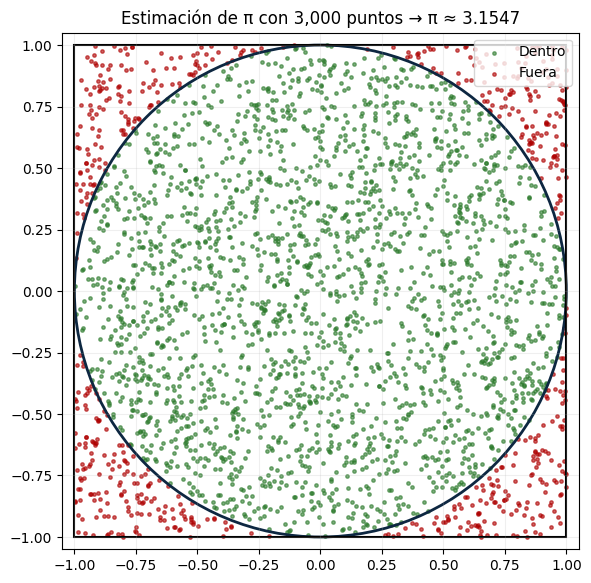

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Visualización del método (versión "viva" del diagrama: puntos reales)
rng   = np.random.default_rng(42)
n_viz = 3000
x = rng.uniform(-1, 1, n_viz)
y = rng.uniform(-1, 1, n_viz)
dentro  = (x**2 + y**2) <= 1
pi_viz  = 4 * dentro.mean()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x[dentro],  y[dentro],  s=6, color="#2c7a2c", alpha=0.6, label="Dentro")
ax.scatter(x[~dentro], y[~dentro], s=6, color="#ae0000", alpha=0.6, label="Fuera")
ax.add_patch(plt.Circle((0, 0), 1, fill=False, color="#0d2741", linewidth=2))
ax.add_patch(plt.Rectangle((-1, -1), 2, 2, fill=False, color="black", linewidth=1.5))
ax.set_xlim(-1.05, 1.05); ax.set_ylim(-1.05, 1.05)
ax.set_aspect("equal")
ax.set_title(f"Estimación de π con {n_viz:,} puntos → π ≈ {pi_viz:.4f}")
ax.legend(loc="upper right")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### 3.2 Implementación y Convergencia

In [5]:
import numpy as np

def estimar_pi_mc(n_muestras, random_state=42):
    """Estimar π mediante Monte Carlo."""
    rng    = np.random.default_rng(random_state)
    x, y   = rng.uniform(-1, 1, n_muestras), rng.uniform(-1, 1, n_muestras)
    p      = ((x**2 + y**2) <= 1).mean()
    pi_est = 4 * p
    se     = 4 * np.sqrt(p * (1 - p) / n_muestras)
    return pi_est, se

print(f"π verdadero: {np.pi:.10f}\n")
print(f"{'n':>10}  {'π estimado':>14}  {'SE':>10}  {'Error':>12}")
print("-" * 55)
for n in [100, 1_000, 10_000, 100_000, 1_000_000, 10_000_000]:
    est, se = estimar_pi_mc(n, random_state=42)
    print(f"{n:>10,}  {est:>14.8f}  {se:>10.6f}  "
          f"{abs(est - np.pi):>12.8f}")

π verdadero: 3.1415926536

         n      π estimado          SE         Error
-------------------------------------------------------
       100      3.12000000    0.165699    0.02159265
     1,000      3.08000000    0.053232    0.06159265
    10,000      3.12560000    0.016532    0.01599265
   100,000      3.14308000    0.005190    0.00148735
 1,000,000      3.14178000    0.001642    0.00018735


10,000,000      3.14148520    0.000519    0.00010745


**Observaciones:** la convergencia es $O(1/\sqrt{n})$; para reducir el error a la mitad se necesitan $4\times$ más muestras. El estimador es insesgado ($E[\hat{\pi}] = \pi$) pero Monte Carlo no es el método más eficiente para estimar $\pi$ en la práctica: su valor es fundamentalmente pedagógico.

## 4. Propagación de Incertidumbre

### 4.1 El Problema

Dado un modelo $Y = f(X_1,\ldots,X_p)$ donde las entradas $X_i$ tienen incertidumbre (errores de medición, variabilidad natural), queremos entender cómo esa incertidumbre se propaga a la salida $Y$.

| Método | Descripción |
|:---|:---|
| Analítico (Taylor) | Aproximación lineal con derivadas. Solo válido para $f$ lineal o casi lineal |
| Monte Carlo | Muestrear distribuciones de entrada, evaluar $f$, analizar salida. Funciona para cualquier $f$ |
| Método Delta | Similar a Taylor, usa Teorema Central del Límite. Aproximado |

### 4.2 Propagación Monte Carlo

> **📘 Definición — Propagación de Incertidumbre vía Monte Carlo**
>
> **Algoritmo:**
> 1. Especificar distribuciones de las variables de entrada: $X_i \sim F_i$
> 2. Para $j = 1,\ldots,n$: generar $(x_1^{(j)},\ldots,x_p^{(j)})$ y evaluar $y^{(j)} = f(x_1^{(j)},\ldots,x_p^{(j)})$
> 3. Analizar la distribución de $\{y^{(1)},\ldots,y^{(n)}\}$: media, varianza, percentiles, IC, probabilidades de eventos
>
> **Ventaja:** Funciona para modelos no lineales, distribuciones no normales y correlaciones complejas.

> **🟢 Ejemplo — Circuito Eléctrico: Ley de Ohm**
>
> $V = IR$, con $I \sim N(2.0,\, 0.1^2)$ A y $R \sim N(100,\, 5^2)\ \Omega$ independientes.

In [6]:
import numpy as np
from scipy import stats

def propagacion_ohm_mc(n=100_000, random_state=42):
    rng = np.random.default_rng(random_state)
    I   = np.abs(rng.normal(2.0, 0.1, n))
    R   = np.abs(rng.normal(100,  5,  n))
    V   = I * R
    return I, R, V

I_sim, R_sim, V_sim = propagacion_ohm_mc()

# Aproximación analítica (regla de propagación para producto)
I_mean, I_std = 2.0,  0.1
R_mean, R_std = 100,  5
V_mean_teo = I_mean * R_mean
V_std_teo  = np.sqrt((I_std * R_mean)**2 + (R_std * I_mean)**2)

print("Resultados Monte Carlo:")
print(f"  Media V:  {V_sim.mean():.4f} V")
print(f"  Desv.Est: {V_sim.std():.4f} V")
print(f"  IC 95%:   [{np.percentile(V_sim, 2.5):.4f}, "
      f"{np.percentile(V_sim, 97.5):.4f}] V")
print("\nAproximación Analítica (Taylor):")
print(f"  Media V:  {V_mean_teo:.4f} V")
print(f"  Desv.Est: {V_std_teo:.4f} V")

# Análisis de sensibilidad
corr_I_V = stats.pearsonr(I_sim, V_sim)[0]
corr_R_V = stats.pearsonr(R_sim, V_sim)[0]
print(f"\nSensibilidad — Correlación I–V: {corr_I_V:.4f}, "
      f"R–V: {corr_R_V:.4f}")

Resultados Monte Carlo:
  Media V:  199.9844 V
  Desv.Est: 14.1806 V
  IC 95%:   [172.8539, 228.3652] V

Aproximación Analítica (Taylor):
  Media V:  200.0000 V
  Desv.Est: 14.1421 V

Sensibilidad — Correlación I–V: 0.7071, R–V: 0.7056


### 4.3 Modelo No Lineal: Péndulo Simple

La ventaja de Monte Carlo sobre la aproximación de Taylor se aprecia especialmente en modelos no lineales.

> **🟢 Ejemplo — Periodo de un péndulo**
>
> $T = 2\pi\sqrt{L/g}$, con $L \sim N(1.0,\, 0.05^2)$ m y $g \sim N(9.81,\, 0.1^2)\ \text{m/s}^2$.

In [7]:
import numpy as np

def propagacion_pendulo(n=100_000, random_state=42):
    rng = np.random.default_rng(random_state)
    L   = np.abs(rng.normal(1.0,  0.05, n))
    g   = np.abs(rng.normal(9.81, 0.10, n))
    T   = 2 * np.pi * np.sqrt(L / g)
    return L, g, T

_, _, T_sim = propagacion_pendulo()

print(f"Periodo T:")
print(f"  Media:    {T_sim.mean():.6f} s")
print(f"  Desv.Est: {T_sim.std():.6f} s")
print(f"  IC 95%:   [{np.percentile(T_sim, 2.5):.6f}, "
      f"{np.percentile(T_sim, 97.5):.6f}] s")

Periodo T:
  Media:    2.005272 s
  Desv.Est: 0.051435 s
  IC 95%:   [1.903098, 2.105036] s


## 5. Intervalos de Confianza por Simulación

### 5.1 Bootstrap

> **📘 Definición — Bootstrap**
>
> **Objetivo:** Estimar la distribución (y error estándar, intervalos de confianza) de un estadístico $\hat{\theta}$ sin supuestos paramétricos.
>
> **Algoritmo:**
> 1. Datos originales: $\mathbf{x} = (x_1,\ldots,x_n)$
> 2. Para $b = 1,\ldots,B$ (típicamente $B \geq 1\,000$):
>     - Generar muestra bootstrap $\mathbf{x}^*_b$ muestreando *con reemplazo* de $\mathbf{x}$
>     - Calcular $\hat{\theta}^*_b = T(\mathbf{x}^*_b)$
> 3. La distribución de $\{\hat{\theta}^*_1,\ldots,\hat{\theta}^*_B\}$ estima la distribución de $\hat{\theta}$
>
> **IC Bootstrap Percentil:**
>
> $$IC_{1-\alpha} = \bigl[\hat{\theta}^*_{\alpha/2},\;\hat{\theta}^*_{1-\alpha/2}\bigr]$$

> **🟢 Ejemplo — IC para la Mediana**

In [8]:
import numpy as np

def bootstrap_ic(datos, estadistico=np.median,
                 n_bootstrap=10_000, confianza=0.95,
                 random_state=42):
    """
    Calcular intervalo de confianza bootstrap.

    Returns
    -------
    estimacion : float       — estadístico en datos originales
    ic         : tuple       — (límite inferior, límite superior)
    boot_dist  : ndarray     — distribución bootstrap completa
    """
    rng              = np.random.default_rng(random_state)
    n                = len(datos)
    estimacion_orig  = estadistico(datos)

    boot_stats = np.array([
        estadistico(rng.choice(datos, size=n, replace=True))
        for _ in range(n_bootstrap)
    ])

    alpha = 1 - confianza
    ic    = (np.percentile(boot_stats, 100 * alpha / 2),
             np.percentile(boot_stats, 100 * (1 - alpha / 2)))

    return estimacion_orig, ic, boot_stats

# Datos asimétricos
rng   = np.random.default_rng(42)
datos = rng.exponential(scale=5, size=100)

med_obs, ic_med, dist_med = bootstrap_ic(datos, np.median)
mea_obs, ic_mea, dist_mea = bootstrap_ic(datos, np.mean)

print("INTERVALOS DE CONFIANZA BOOTSTRAP (n=100)")
print("-" * 55)
print(f"Mediana: {med_obs:.4f}  IC 95%: [{ic_med[0]:.4f}, {ic_med[1]:.4f}]"
      f"  Amplitud: {ic_med[1]-ic_med[0]:.4f}")
print(f"Media:   {mea_obs:.4f}  IC 95%: [{ic_mea[0]:.4f}, {ic_mea[1]:.4f}]"
      f"  Amplitud: {ic_mea[1]-ic_mea[0]:.4f}")

INTERVALOS DE CONFIANZA BOOTSTRAP (n=100)
-------------------------------------------------------
Mediana: 3.0348  IC 95%: [1.9888, 4.6241]  Amplitud: 2.6353
Media:   4.4953  IC 95%: [3.6799, 5.4087]  Amplitud: 1.7288


## 6. Comparación de Métodos

| Método | Ventajas | Desventajas | Cuándo usar |
|:---|:---|:---|:---|
| **Analítico** | Exacto, rápido | Solo funciones simples | Modelos lineales, normales |
| **Cuadratura** | Preciso en 1D | Maldición de la dimensionalidad | Integrales 1D, 2D |
| **Monte Carlo** | Funciona siempre, escalable | Lento, aproximado | Modelos complejos, alta dimensión |
| **Bootstrap** | Sin supuestos, robusto | Computacionalmente intensivo | ICs sin teoría asintótica |

## 7. Resumen y Puntos Clave

1. Monte Carlo permite **estimar integrales** reformulándolas como expectativas que se aproximan mediante muestreo.
2. La **integración Monte Carlo** tiene error $O(1/\sqrt{n})$ independiente de la dimensión, lo que la hace especialmente ventajosa en alta dimensión.
3. La **estimación de $\pi$** es el ejemplo clásico: muestrear puntos uniformes, contar cuántos caen en el círculo y multiplicar la proporción por 4.
4. **Propagación de incertidumbre:** muestrear distribuciones de entrada, evaluar el modelo y analizar la distribución de la salida. Funciona para modelos no lineales donde la aproximación de Taylor falla.
5. **Bootstrap** usa Monte Carlo para estimar distribuciones de estadísticos mediante remuestreo con reemplazo.
6. Los **intervalos de confianza** por simulación no requieren supuestos paramétricos ni teoría asintótica.
7. Monte Carlo es especialmente valioso cuando el modelo es complejo, no lineal o de alta dimensión.
8. La convergencia es lenta ($1/\sqrt{n}$), pero el método es robusto, flexible y paralelizable.
9. Siempre verificar convergencia, usar semillas para reproducibilidad y reportar errores estándar junto con los resultados.

### Cierre

> 💡 Monte Carlo transforma problemas de cálculo en problemas de muestreo. Esta reformulación permite abordar integrales complejas, propagar incertidumbre a través de modelos no lineales y construir intervalos de confianza sin supuestos fuertes. Aunque la convergencia es lenta, la flexibilidad y generalidad del método lo hacen indispensable en ciencia de datos moderna, especialmente cuando la complejidad del modelo hace intratables los enfoques analíticos tradicionales. Comprender cuándo y cómo aplicar Monte Carlo es una de las habilidades más transferibles en estadística computacional.